# 🐝 Spelling Bee — My Performance

Statistics derived from `data/merged_db.json`.
Each entry is one puzzle date: found and missed words are resolved authoritatively against the nytbee reference database, so the "missed" list is always complete even when the screenshot OCR was imperfect.

In [1]:
import json
import warnings
import calendar
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime, date as date_type

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

C_FOUND   = "#F7C948"   # yellow  — found
C_MISSED  = "#E06B3C"   # coral   — missed
C_PANGRAM = "#9C27B0"   # purple  — pangrams
C_BLUE    = "#4A90D9"
C_GREEN   = "#2E8B57"   # green   — score / points
C_BG      = "#FAFAFA"

ROOT      = Path("..")
MERGED_DB = ROOT / "data" / "merged_db.json"
DEFS_DB   = ROOT / "data" / "definitions_db.json"

with open(MERGED_DB) as f:
    merged = json.load(f)
with open(DEFS_DB) as f:
    definitions = json.load(f)


def score_word(word: str, pangrams: set) -> int:
    """NYT scoring: 4 letters = 1 pt, 5+ letters = 1 pt/letter, pangram = +7."""
    n = len(word)
    return (1 if n == 4 else n) + (7 if word.lower() in pangrams else 0)


rows = []
for date_str, v in merged.items():
    date     = datetime.strptime(date_str, "%Y-%m-%d")
    found    = [w.lower() for w in v.get("found",    [])]
    missed   = [w.lower() for w in v.get("missed",   [])]
    pangrams = [w.lower() for w in v.get("pangrams", [])]
    total    = len(found) + len(missed)
    n_pg_f   = sum(1 for p in pangrams if p in found)
    pg_set   = set(pangrams)
    pts_e    = sum(score_word(w, pg_set) for w in found)
    pts_p    = sum(score_word(w, pg_set) for w in found + missed)
    rows.append({
        "date":            date,
        "date_str":        date_str,
        "found":           found,
        "missed":          missed,
        "pangrams":        pangrams,
        "total":           total,
        "n_found":         len(found),
        "n_missed":        len(missed),
        "miss_rate":       len(missed) / total if total else 0.0,
        "pangrams_total":  len(pangrams),
        "pangrams_found":  n_pg_f,
        "pangrams_missed": len(pangrams) - n_pg_f,
        "puzzle_letters":  v.get("puzzle_letters", []),
        "center_letter":   v.get("center_letter", ""),
        "points_earned":   pts_e,
        "points_possible": pts_p,
        "points_missed":   pts_p - pts_e,
        "score_pct":       pts_e / pts_p if pts_p else 0.0,
    })

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
df["dow"]  = df["date"].dt.dayofweek   # 0=Mon
df["year"] = df["date"].dt.year

print(f"Loaded {len(df)} puzzles  ·  {df['date'].min().date()} → {df['date'].max().date()}")

Loaded 664 puzzles  ·  2024-02-12 → 2026-04-26


## 1. Overall Scoreboard

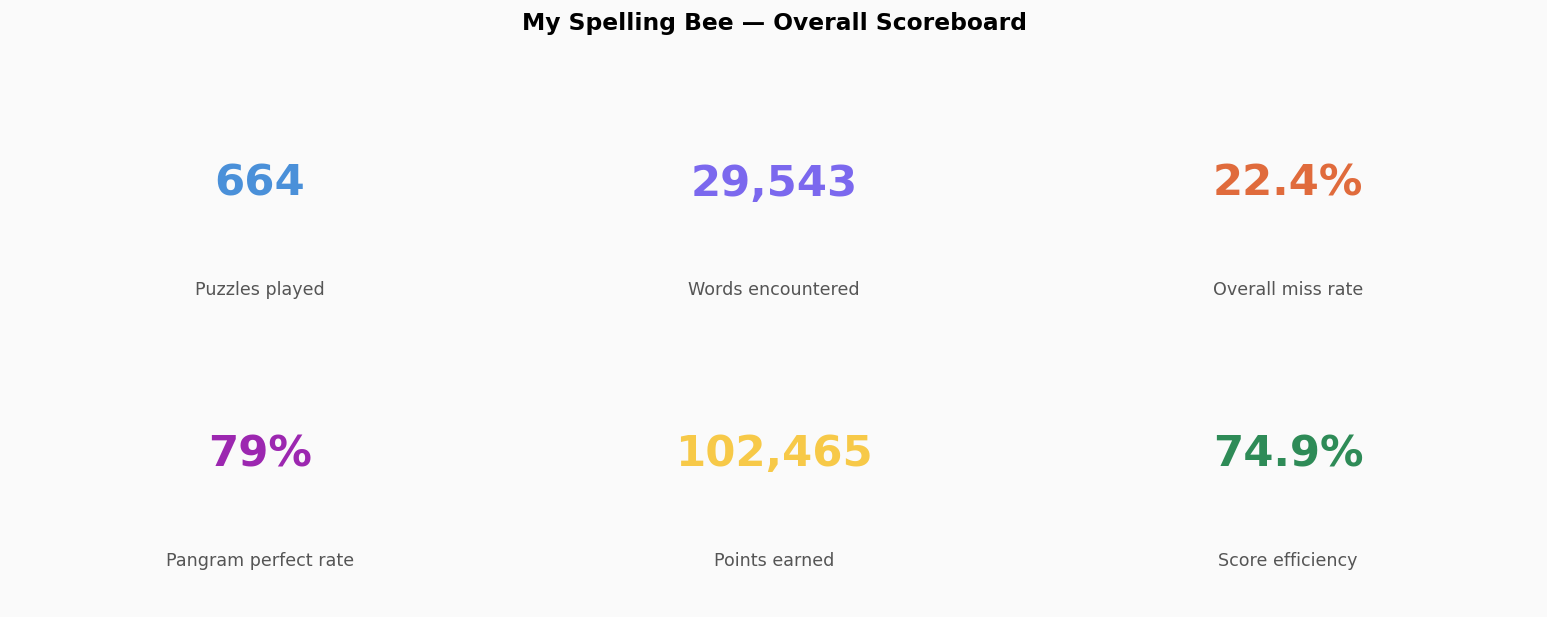

In [2]:
total_puzzles     = len(df)
total_words       = df["total"].sum()
total_missed      = df["n_missed"].sum()
overall_miss_rate = total_missed / total_words * 100
found_all_pg      = (df["pangrams_missed"] == 0).sum()
pangram_rate      = found_all_pg / total_puzzles * 100
total_pts_earned  = df["points_earned"].sum()
total_pts_poss    = df["points_possible"].sum()
overall_score_pct = total_pts_earned / total_pts_poss * 100

fig, axes = plt.subplots(2, 3, figsize=(13, 5.0), facecolor=C_BG)
fig.suptitle("My Spelling Bee — Overall Scoreboard", fontsize=14, fontweight="bold", y=1.02)

cards = [
    ("Puzzles played",       f"{total_puzzles:,}",         C_BLUE),
    ("Words encountered",    f"{total_words:,}",           "#7B68EE"),
    ("Overall miss rate",    f"{overall_miss_rate:.1f}%",  C_MISSED),
    ("Pangram perfect rate", f"{pangram_rate:.0f}%",       C_PANGRAM),
    ("Points earned",        f"{total_pts_earned:,}",      C_FOUND),
    ("Score efficiency",     f"{overall_score_pct:.1f}%",  C_GREEN),
]
for ax, (label, val, color) in zip(axes.flat, cards):
    ax.set_facecolor("white")
    ax.text(0.5, 0.60, val,   ha="center", va="center", fontsize=26, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha="center", va="center", fontsize=10.5, color="#555",
            transform=ax.transAxes)
    ax.axis("off")
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color("#E0E0E0"); sp.set_linewidth(1.5)

plt.tight_layout()
plt.show()

## 2. Miss Rate Over Time

The scattered dots are individual puzzles; the line is a 28-puzzle rolling average. Downward trends mean improvement.

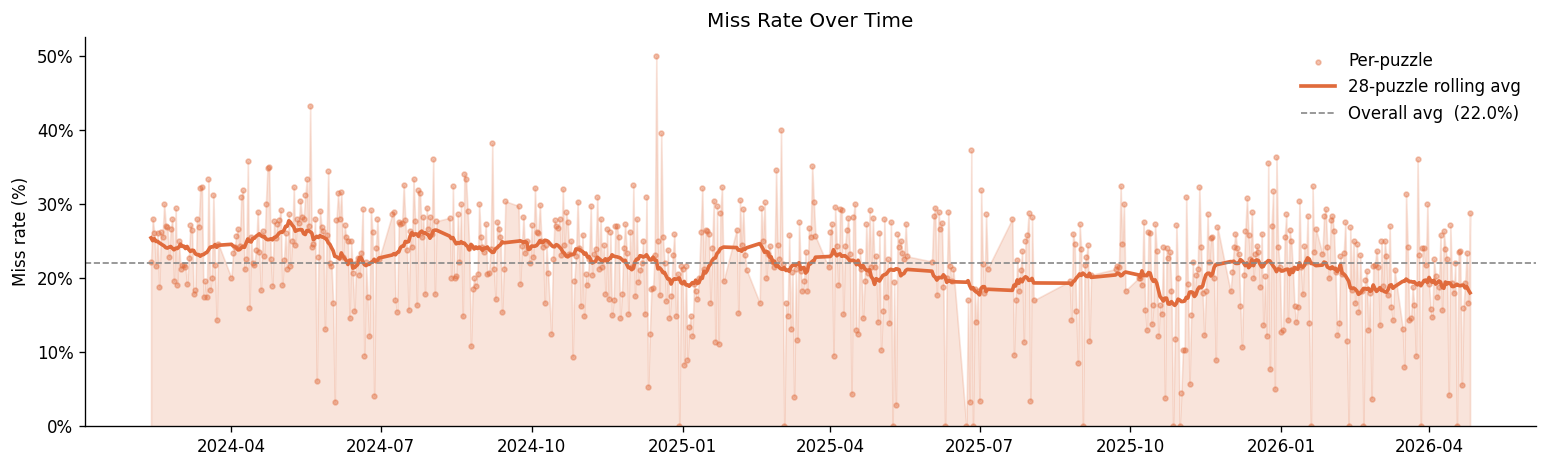

In [3]:
roll = df["miss_rate"].rolling(28, min_periods=5, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(df["date"], df["miss_rate"] * 100, alpha=0.18, color=C_MISSED)
ax.scatter(df["date"], df["miss_rate"] * 100, s=8, alpha=0.4, color=C_MISSED, label="Per-puzzle")
ax.plot(df["date"], roll * 100, color=C_MISSED, linewidth=2.2, label="28-puzzle rolling avg")
ax.axhline(df["miss_rate"].mean() * 100, color="#888", linestyle="--", linewidth=1,
           label=f"Overall avg  ({df['miss_rate'].mean()*100:.1f}%)")
ax.set_ylabel("Miss rate (%)")
ax.set_title("Miss Rate Over Time")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Calendar Heatmap

Each square is one puzzle. Colour runs green → yellow → red with miss rate.
Grey squares are days with no recorded puzzle.

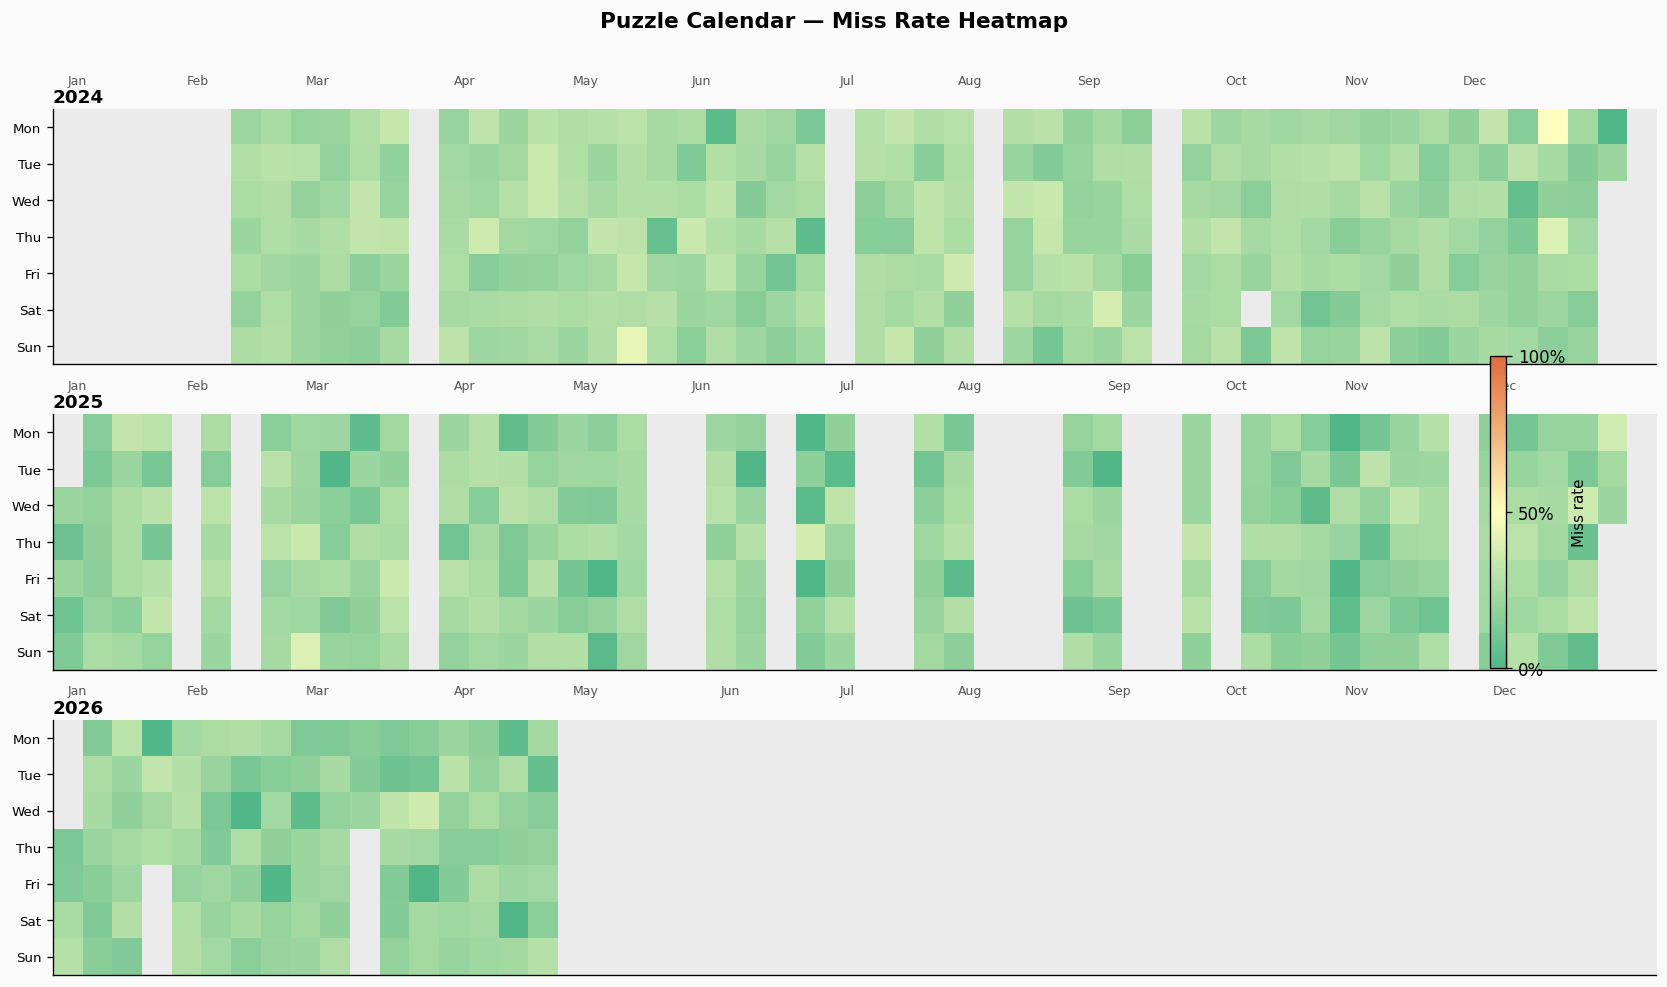

In [4]:
miss_by_date = dict(zip(df["date_str"], df["miss_rate"]))
cmap = LinearSegmentedColormap.from_list("bee", ["#52B788", "#FFFFBF", C_MISSED], N=256)

years = sorted(df["year"].unique())
fig, axes = plt.subplots(len(years), 1,
                         figsize=(14, 2.7 * len(years)),
                         facecolor=C_BG)
if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    grid  = np.full((7, 54), np.nan)
    jan1  = date_type(year, 1, 1)
    jan1_dow = jan1.weekday()   # 0=Mon

    for d_str, rate in miss_by_date.items():
        d = datetime.strptime(d_str, "%Y-%m-%d").date()
        if d.year != year:
            continue
        offset = (d - jan1).days
        col    = (offset + jan1_dow) // 7
        row    = d.weekday()
        if 0 <= col < 54:
            grid[row, col] = rate

    masked = np.ma.masked_invalid(grid)
    cmap.set_bad("#EBEBEB")
    img = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1,
                    aspect="auto", interpolation="none")

    ax.set_yticks(range(7))
    ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], fontsize=8)
    ax.set_xticks([])
    ax.set_title(str(year), fontsize=11, fontweight="bold", loc="left", pad=4)

    for month in range(1, 13):
        first  = date_type(year, month, 1)
        offset = (first - jan1).days
        col    = (offset + jan1_dow) // 7
        ax.text(col, -1.1, calendar.month_abbr[month],
                fontsize=7.5, ha="left", va="bottom", color="#555")

cb = fig.colorbar(img, ax=axes, orientation="vertical", fraction=0.012, pad=0.01)
cb.set_label("Miss rate", fontsize=9)
cb.set_ticks([0, 0.5, 1.0])
cb.set_ticklabels(["0%", "50%", "100%"])

fig.suptitle("Puzzle Calendar — Miss Rate Heatmap", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. Performance by Day of Week

Error bars show ±1 standard error. Labels show the number of puzzles per day.

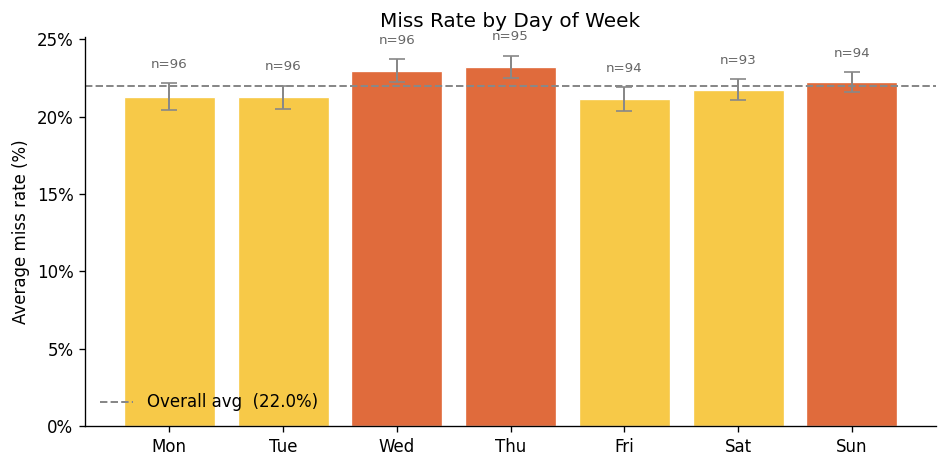

In [5]:
DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_stats = df.groupby("dow")["miss_rate"].agg(mean="mean", sem="sem", count="count")
overall_avg = df["miss_rate"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [C_MISSED if r > df["miss_rate"].mean() else C_FOUND for r in dow_stats["mean"]]
ax.bar(
    DOW_NAMES, dow_stats["mean"] * 100,
    yerr=dow_stats["sem"] * 100, capsize=5,
    color=bar_colors, edgecolor="white", linewidth=0.8,
    error_kw={"elinewidth": 1.2, "ecolor": "#888"},
)
ax.axhline(overall_avg, color="#888", linestyle="--", linewidth=1.2,
           label=f"Overall avg  ({overall_avg:.1f}%)")
ax.set_ylabel("Average miss rate (%)")
ax.set_title("Miss Rate by Day of Week")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(frameon=False)

for i, (_, row) in enumerate(dow_stats.iterrows()):
    ax.text(i, row["mean"] * 100 + row["sem"] * 100 + 1.0,
            f"n={int(row['count'])}", ha="center", fontsize=8, color="#666")

plt.tight_layout()
plt.show()

## 5. Hardest Puzzles

Top 10 by miss rate (minimum 10 words to qualify).

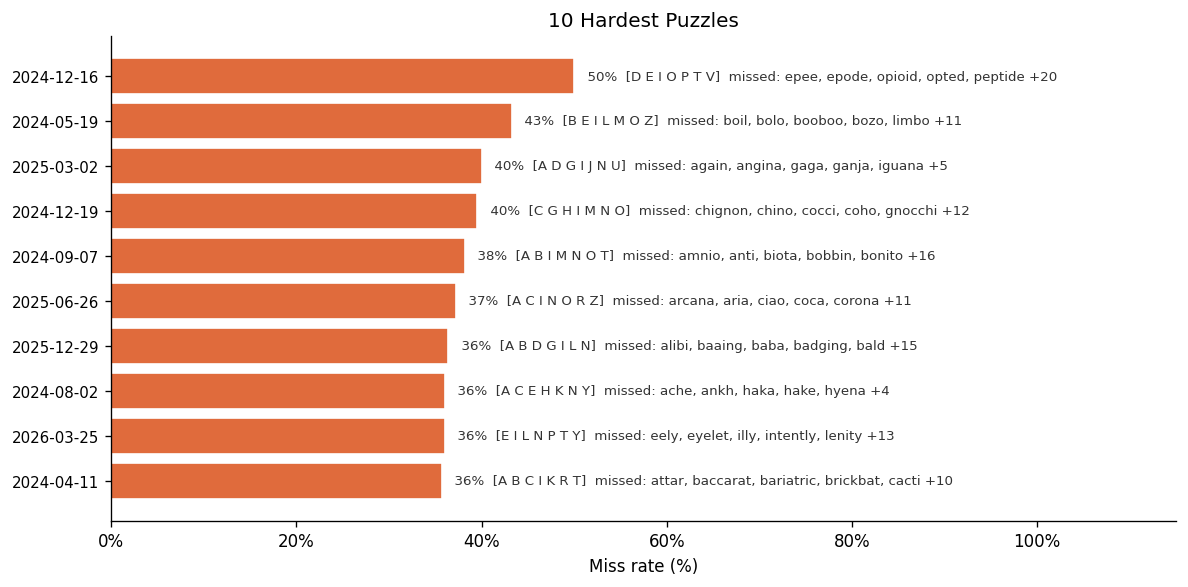

In [6]:
hard = (
    df[df["total"] >= 10]
    .nlargest(10, "miss_rate")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(hard.index, hard["miss_rate"] * 100, color=C_MISSED, edgecolor="white")
ax.set_yticks(hard.index)
ax.set_yticklabels(hard["date_str"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Miss rate (%)")
ax.set_title("10 Hardest Puzzles")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

for i, row in hard.iterrows():
    letters = " ".join(l.upper() for l in sorted(row["puzzle_letters"]))
    top_missed = ", ".join(sorted(row["missed"])[:5])
    if len(row["missed"]) > 5:
        top_missed += f" +{len(row['missed'])-5}"
    label = f"  {row['miss_rate']*100:.0f}%  [{letters}]  missed: {top_missed}"
    ax.text(row["miss_rate"] * 100 + 0.5, i, label, va="center", fontsize=8, color="#333")

ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

## 6. Miss Rate by Distinct-Letter Count

Each word in the bee uses between 4 and 7 distinct letters (4-letter minimum word length,
7-letter maximum alphabet subset). Does complexity within that range affect your recall?

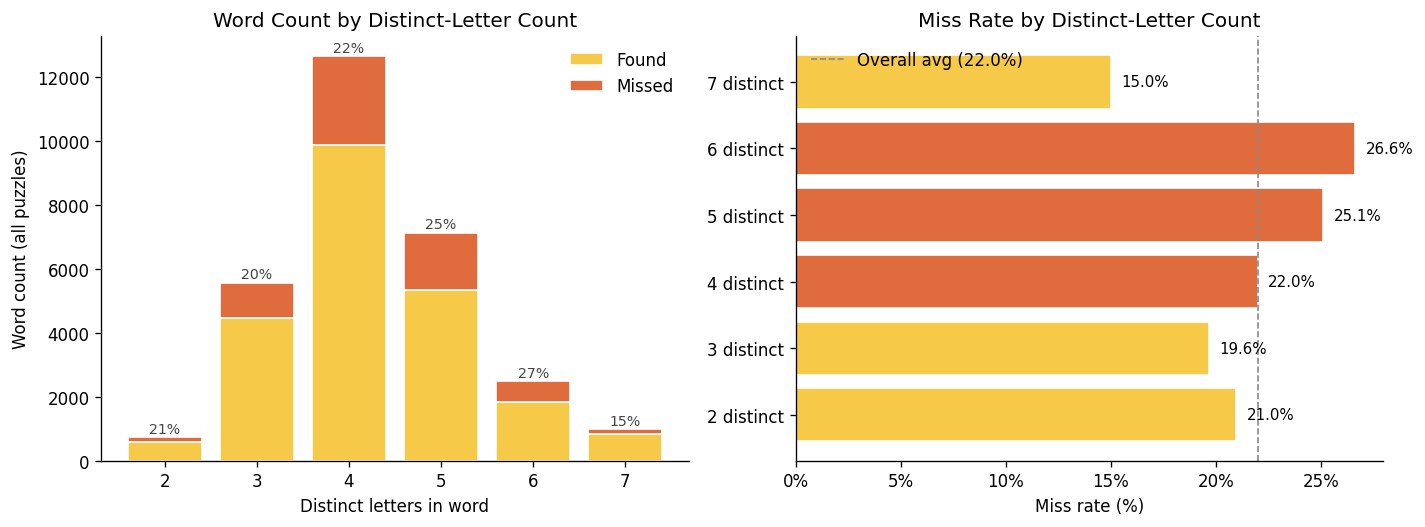

In [7]:
by_n = defaultdict(lambda: {"total": 0, "missed": 0})
for _, row in df.iterrows():
    for w in row["found"] + row["missed"]:
        n = len(set(w))
        if 2 <= n <= 7:
            by_n[n]["total"] += 1
    for w in row["missed"]:
        n = len(set(w))
        if 2 <= n <= 7:
            by_n[n]["missed"] += 1

ns      = sorted(by_n)
totals  = [by_n[n]["total"]  for n in ns]
misses  = [by_n[n]["missed"] for n in ns]
found_c = [t - m for t, m in zip(totals, misses)]
rates   = [m / t * 100 if t else 0 for m, t in zip(misses, totals)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.bar(ns, found_c, color=C_FOUND,  label="Found",  edgecolor="white")
ax1.bar(ns, misses,  bottom=found_c, color=C_MISSED, label="Missed", edgecolor="white")
ax1.set_xlabel("Distinct letters in word")
ax1.set_ylabel("Word count (all puzzles)")
ax1.set_title("Word Count by Distinct-Letter Count")
ax1.set_xticks(ns)
ax1.legend(frameon=False)
for n, t, m in zip(ns, totals, misses):
    ax1.text(n, t + max(totals)*0.01, f"{m/t*100:.0f}%", ha="center", fontsize=8.5, color="#444")

bar_colors = [C_MISSED if r >= df["miss_rate"].mean()*100 else C_FOUND for r in rates]
ax2.barh(ns, rates, color=bar_colors, edgecolor="white")
ax2.axvline(df["miss_rate"].mean() * 100, color="#888", linestyle="--", linewidth=1,
            label=f"Overall avg ({df['miss_rate'].mean()*100:.1f}%)")
ax2.set_xlabel("Miss rate (%)")
ax2.set_title("Miss Rate by Distinct-Letter Count")
ax2.set_yticks(ns)
ax2.set_yticklabels([f"{n} distinct" for n in ns])
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax2.legend(frameon=False)
for n, r in zip(ns, rates):
    ax2.text(r + 0.5, n, f"{r:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Most-Missed Words

Words you missed across the most puzzles, with their definitions from the cache.

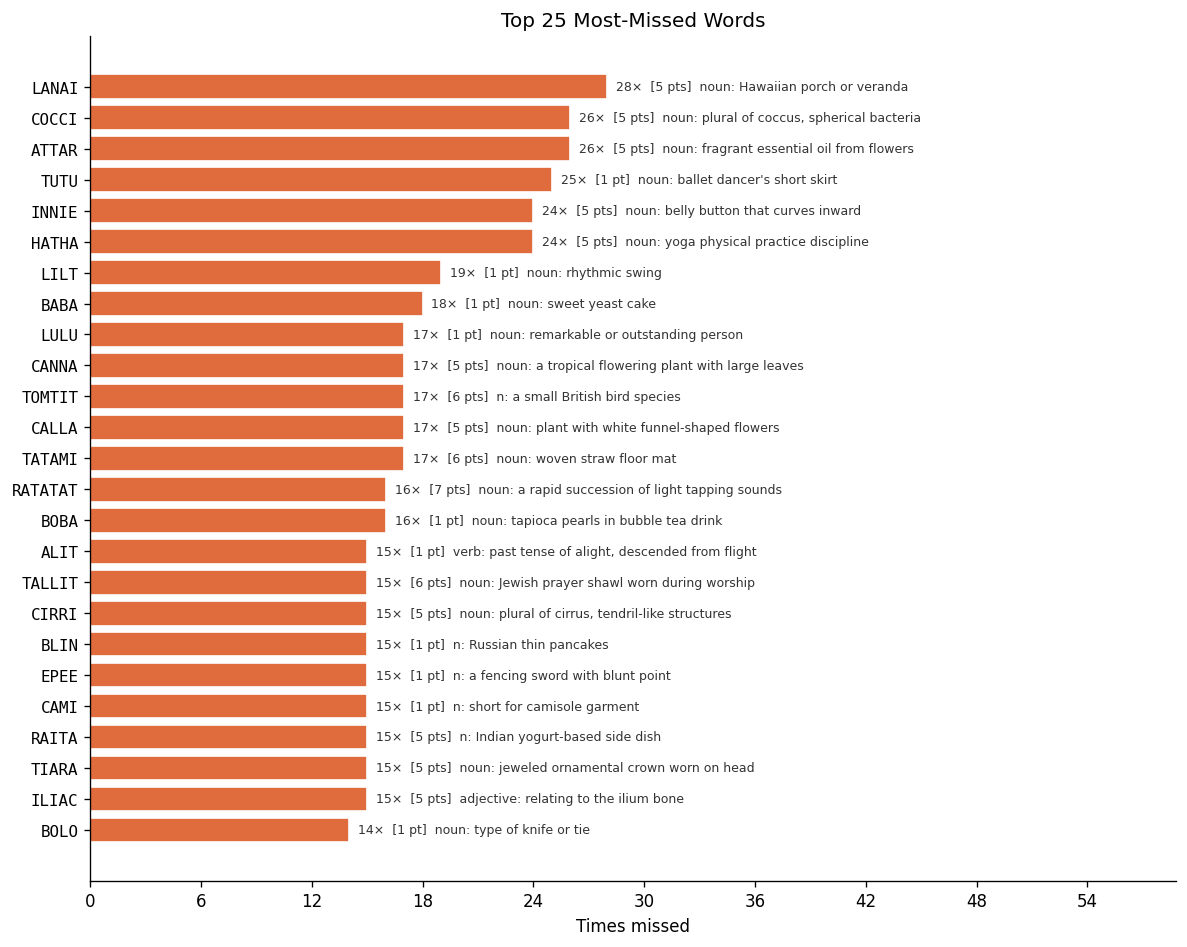

In [8]:
missed_ctr: Counter = Counter()
for _, row in df.iterrows():
    missed_ctr.update(row["missed"])

all_pangrams = {pg for _, row in df.iterrows() for pg in row["pangrams"]}

top_n  = 25
top    = missed_ctr.most_common(top_n)
words  = [w for w, _ in top]
counts = [c for _, c in top]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(words)), counts, color=C_MISSED, edgecolor="white")
ax.set_yticks(range(len(words)))
ax.set_yticklabels([w.upper() for w in words], fontsize=9.5, fontfamily="monospace")
ax.invert_yaxis()
ax.set_xlabel("Times missed")
ax.set_title(f"Top {top_n} Most-Missed Words")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

for bar, word, count in zip(bars, words, counts):
    pts     = score_word(word, all_pangrams)
    defn    = definitions.get(word) or ""
    snippet = (defn[:55] + "…") if len(defn) > 55 else defn
    ax.text(count + 0.05, bar.get_y() + bar.get_height() / 2,
            f"  {count}×  [{pts} pt{'s' if pts != 1 else ''}]  {snippet}",
            va="center", fontsize=7.5, color="#333")

ax.set_xlim(right=ax.get_xlim()[1] * 2.0)
plt.tight_layout()
plt.show()

## 8. Pangram Performance

A pangram uses all 7 puzzle letters and is always the most prestigious find.

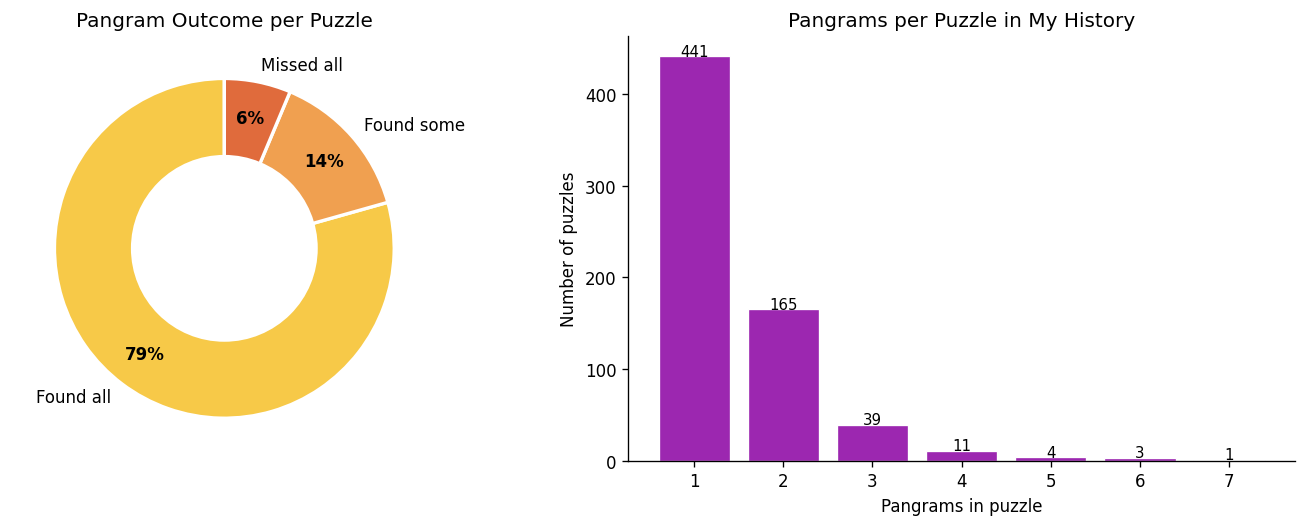

Found ALL  pangrams:  527  (79%)
Found SOME pangrams:   95  (14%)
Missed ALL pangrams:   42  (6%)


In [9]:
found_all  = (df["pangrams_missed"] == 0).sum()
found_some = ((df["pangrams_missed"] > 0) & (df["pangrams_found"] > 0)).sum()
missed_all = (df["pangrams_found"]  == 0).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

wedges, _, autotexts = ax1.pie(
    [found_all, found_some, missed_all],
    labels=["Found all", "Found some", "Missed all"],
    colors=[C_FOUND, "#F0A050", C_MISSED],
    autopct="%1.0f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.78,
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold")
ax1.add_patch(plt.Circle((0, 0), 0.55, fc="white"))
ax1.set_title("Pangram Outcome per Puzzle", fontsize=12)

pg_dist = df["pangrams_total"].value_counts().sort_index()
ax2.bar(pg_dist.index.astype(str), pg_dist.values,
        color=C_PANGRAM, edgecolor="white", linewidth=0.8)
ax2.set_xlabel("Pangrams in puzzle")
ax2.set_ylabel("Number of puzzles")
ax2.set_title("Pangrams per Puzzle in My History")
for i, (cnt, val) in enumerate(pg_dist.items()):
    ax2.text(i, val + 0.5, f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Found ALL  pangrams: {found_all:>4}  ({found_all/len(df)*100:.0f}%)")
print(f"Found SOME pangrams: {found_some:>4}  ({found_some/len(df)*100:.0f}%)")
print(f"Missed ALL pangrams: {missed_all:>4}  ({missed_all/len(df)*100:.0f}%)")

## 9. Word-Length Distribution

Do you miss short words (slipped your mind) or long words (too complex to recall)?

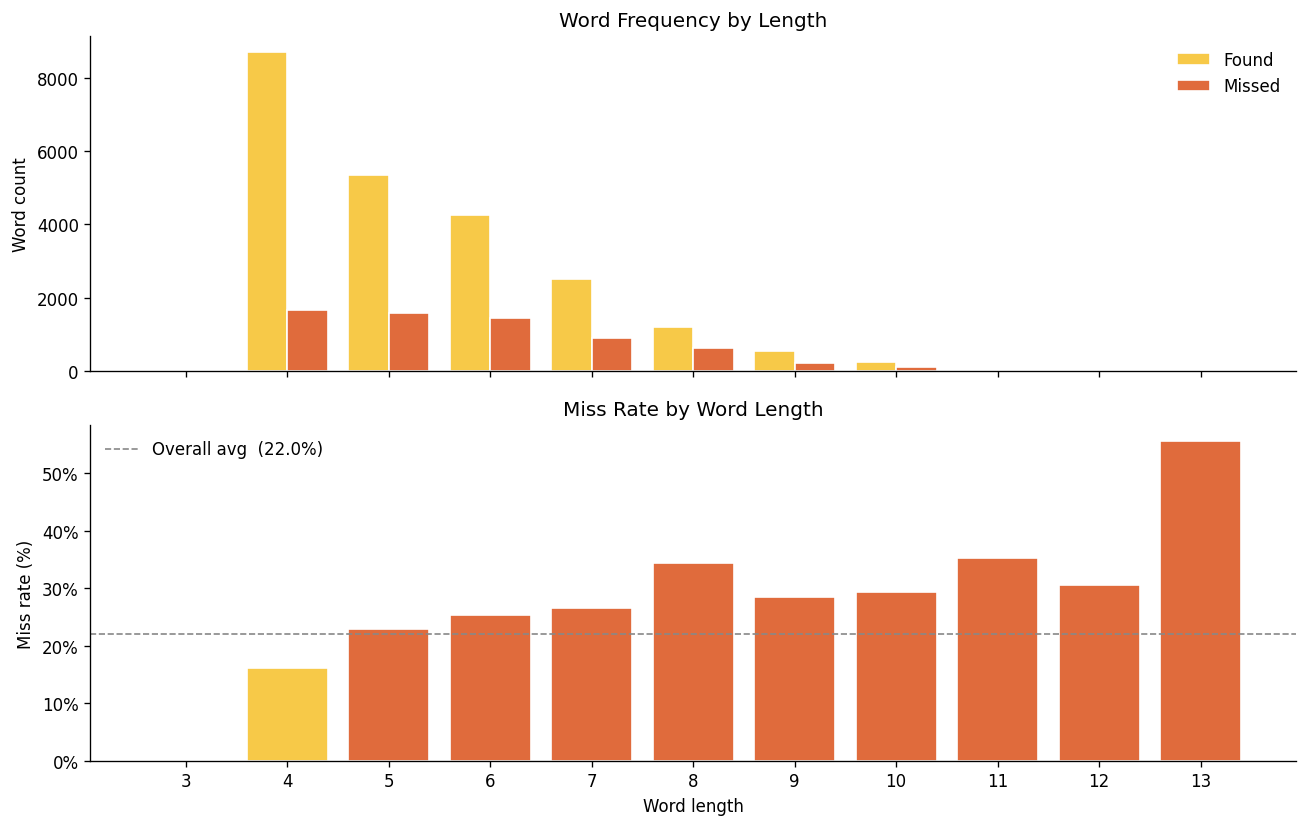

In [10]:
found_lens  = [len(w) for _, r in df.iterrows() for w in r["found"]]
missed_lens = [len(w) for _, r in df.iterrows() for w in r["missed"]]

min_l   = min(found_lens + missed_lens)
max_l   = max(found_lens + missed_lens)
lengths = list(range(min_l, max_l + 1))

fc = Counter(found_lens)
mc = Counter(missed_lens)
f_vals  = [fc.get(l, 0) for l in lengths]
m_vals  = [mc.get(l, 0) for l in lengths]
t_vals  = [f + m for f, m in zip(f_vals, m_vals)]
mr_vals = [m / t * 100 if t else 0 for m, t in zip(m_vals, t_vals)]
x = np.array(lengths)
w = 0.4

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.bar(x - w/2, f_vals, w, color=C_FOUND,  label="Found",  edgecolor="white")
ax1.bar(x + w/2, m_vals, w, color=C_MISSED, label="Missed", edgecolor="white")
ax1.set_ylabel("Word count")
ax1.set_title("Word Frequency by Length")
ax1.legend(frameon=False)

ax2.bar(x, mr_vals,
        color=[C_MISSED if r >= df["miss_rate"].mean()*100 else C_FOUND for r in mr_vals],
        edgecolor="white")
ax2.axhline(df["miss_rate"].mean() * 100, color="#888", linestyle="--", linewidth=1,
            label=f"Overall avg  ({df['miss_rate'].mean()*100:.1f}%)")
ax2.set_ylabel("Miss rate (%)")
ax2.set_xlabel("Word length")
ax2.set_title("Miss Rate by Word Length")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax2.set_xticks(lengths)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

## 10. Miss Rate by Center Letter

Some center letters may suit your vocabulary better than others.
Only letters with ≥ 3 puzzles are shown.

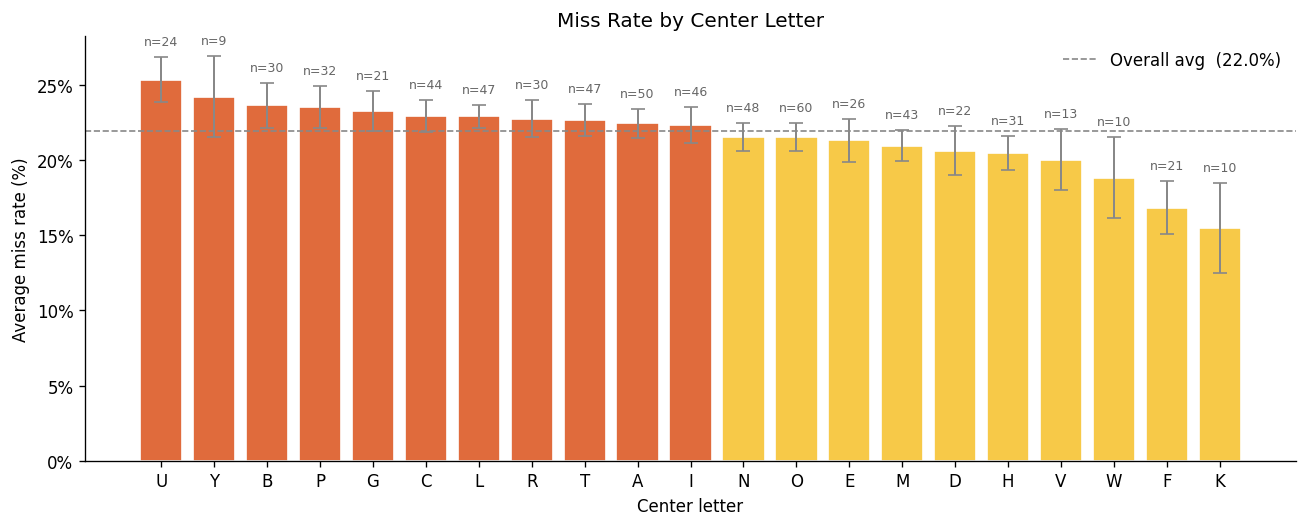

In [11]:
cl_stats = (
    df.groupby("center_letter")["miss_rate"]
    .agg(mean="mean", sem="sem", count="count")
    .query("count >= 3")
    .sort_values("mean", ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 4.5))
bar_colors = [C_MISSED if r > df["miss_rate"].mean() else C_FOUND for r in cl_stats["mean"]]
ax.bar(
    cl_stats.index.str.upper(), cl_stats["mean"] * 100,
    yerr=cl_stats["sem"] * 100, capsize=4,
    color=bar_colors, edgecolor="white",
    error_kw={"elinewidth": 1.2, "ecolor": "#888"},
)
ax.axhline(df["miss_rate"].mean() * 100, color="#888", linestyle="--", linewidth=1,
           label=f"Overall avg  ({df['miss_rate'].mean()*100:.1f}%)")
ax.set_xlabel("Center letter")
ax.set_ylabel("Average miss rate (%)")
ax.set_title("Miss Rate by Center Letter")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(frameon=False)

for i, (letter, row) in enumerate(cl_stats.iterrows()):
    ax.text(i, row["mean"] * 100 + row["sem"] * 100 + 0.8,
            f"n={int(row['count'])}", ha="center", fontsize=7.5, color="#666")

plt.tight_layout()
plt.show()

## 11. Score Efficiency Over Time

Score efficiency weights each word by its point value: missing a 10-point pangram costs far more than missing a 1-point 4-letter word. When efficiency (green) dips below found rate (yellow), you're disproportionately missing high-value words.

In [ ]:
score_roll = df["score_pct"].rolling(28, min_periods=5, center=True).mean()
found_roll = (1 - df["miss_rate"]).rolling(28, min_periods=5, center=True).mean()

perfect   = df["score_pct"] == 1.0
n_perfect = perfect.sum()

fig, ax = plt.subplots(figsize=(13, 4))

# Rating bands
ax.axhspan(70, 100, alpha=0.04, color=C_PANGRAM, zorder=0)
ax.axhspan(50,  70, alpha=0.04, color=C_FOUND,   zorder=0)

# Rating threshold lines
ax.axhline(70, color=C_PANGRAM, linewidth=1.0, linestyle="--", zorder=1)
ax.axhline(50, color=C_FOUND,   linewidth=1.0, linestyle="--", zorder=1)
ax.text(df["date"].max(), 68.2, "Genius",  color=C_PANGRAM, fontsize=8.5, fontweight="bold", ha="right")
ax.text(df["date"].max(), 48.2, "Amazing", color="#C49A00",  fontsize=8.5, fontweight="bold", ha="right")

# Data
ax.fill_between(df["date"], df["score_pct"] * 100, alpha=0.15, color=C_GREEN)
ax.scatter(df.loc[~perfect, "date"], df.loc[~perfect, "score_pct"] * 100,
           s=8, alpha=0.4, color=C_GREEN, label="Per-puzzle  (pts earned / pts possible)")
ax.scatter(df.loc[perfect, "date"], df.loc[perfect, "score_pct"] * 100,
           s=60, marker="*", color=C_FOUND, zorder=5,
           label=f"Perfect score  (100%,  n={n_perfect})")
ax.plot(df["date"], score_roll * 100, color=C_GREEN, linewidth=2.2,
        label="28-puzzle rolling avg  (score efficiency)")
ax.plot(df["date"], found_roll * 100, color="#AAAAAA", linewidth=1.5, linestyle="--",
        label="Found rate by word count  (rolling avg)")
ax.axhline(df["score_pct"].mean() * 100, color="#888", linestyle=":", linewidth=1,
           label=f"Overall score efficiency  ({df['score_pct'].mean()*100:.1f}%)")

ax.set_ylabel("Score efficiency (%)")
ax.set_title("Score Efficiency Over Time  (points earned / points possible)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

gap = (df["score_pct"] - (1 - df["miss_rate"])).mean()
print(f"Found rate:       {(1 - df['miss_rate']).mean()*100:.1f}%")
print(f"Score efficiency: {df['score_pct'].mean()*100:.1f}%")
direction = "above" if gap < 0 else "below"
print(f"→ you tend to miss words of {direction}-average point value  ({abs(gap)*100:.1f} pp gap)")

## 12. Points Left on the Table

Points missed per puzzle reveals sessions where you left the most value behind — either many words missed, or specifically high-value ones.

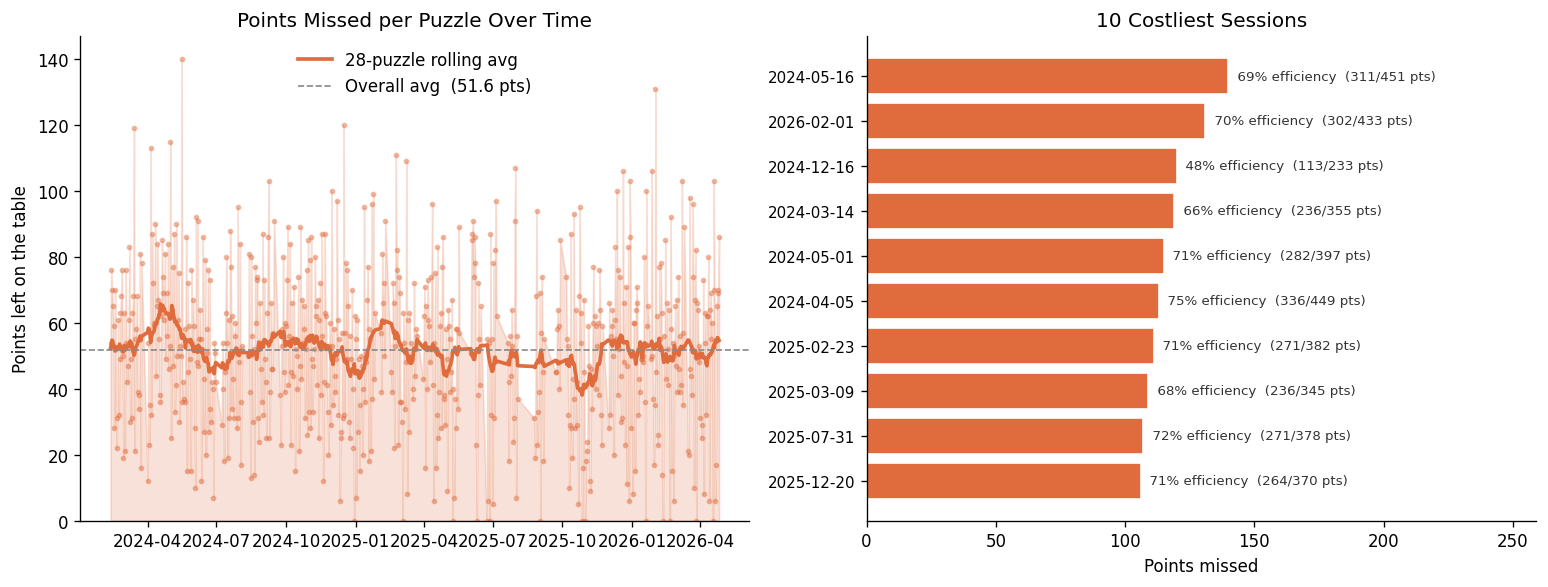

In [13]:
pts_roll = df["points_missed"].rolling(28, min_periods=5, center=True).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.fill_between(df["date"], df["points_missed"], alpha=0.20, color=C_MISSED)
ax1.scatter(df["date"], df["points_missed"], s=6, alpha=0.4, color=C_MISSED)
ax1.plot(df["date"], pts_roll, color=C_MISSED, linewidth=2.2, label="28-puzzle rolling avg")
ax1.axhline(df["points_missed"].mean(), color="#888", linestyle="--", linewidth=1,
            label=f"Overall avg  ({df['points_missed'].mean():.1f} pts)")
ax1.set_ylabel("Points left on the table")
ax1.set_title("Points Missed per Puzzle Over Time")
ax1.legend(frameon=False)
ax1.set_ylim(bottom=0)

worst = df.nlargest(10, "points_missed").reset_index(drop=True)
ax2.barh(worst.index, worst["points_missed"], color=C_MISSED, edgecolor="white")
ax2.set_yticks(worst.index)
ax2.set_yticklabels(worst["date_str"], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel("Points missed")
ax2.set_title("10 Costliest Sessions")
for i, row in worst.iterrows():
    label = (f"  {row['score_pct']*100:.0f}% efficiency"
             f"  ({int(row['points_earned'])}/{int(row['points_possible'])} pts)")
    ax2.text(row["points_missed"] + 0.2, i, label, va="center", fontsize=8, color="#333")
ax2.set_xlim(right=worst["points_missed"].max() * 1.85)

plt.tight_layout()
plt.show()